In [1]:
#import libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import(accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

In [6]:
#load dataset
df= pd.read_csv("healthcare_dataset.csv")

df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df["Date of Admission"]).dt.days

#create target variable (binary classification)
#1 = abmormal test results (high risk)
#0 = normal results (low risk)
df['High Risk'] = (df['Test Results'] == "Abnormal").astype(int)

print("Target Distribution:")
print(df['High Risk'].value_counts())
#print("\nHigh Risk Rate: {df['High Risk'].mean()*100:,1f}%")

Target Distribution:
High Risk
0    36873
1    18627
Name: count, dtype: int64


In [7]:
#feature engineering
features = ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Insurance Provider', 'Billing Amount', 'Length of Stay']
df_model = df[features +['High Risk'].copy()]
le = LabelEncoder()

categorical_col = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Insurance Provider']
for col in categorical_col:
    df_model[col] = le.fit_transform(df_model[col])

print('Shape after feature engineering:', df_model.shape)
df_model.head()

Shape after feature engineering: (55500, 9)


,Age,Gender,Blood Type,Medical Condition,Admission Type,Insurance Provider,Billing Amount,Length of Stay,High Risk
0,30,1,5,2,2,1,18856.281306,2,0
1,62,1,0,5,1,3,33643.327287,6,0
2,76,0,1,5,1,0,27955.096079,15,0
3,28,0,6,3,0,3,37909.782410,30,1
4,43,0,2,2,2,0,14238.317814,20,1


In [8]:
#split feature and target
X = df_model.drop('High Risk', axis=1)
y = df_model['High Risk']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Class distribution:\n", y.value_counts())

Feature shape: (55500, 8)
Target shape: (55500,)
Class distribution:
 High Risk
0    36873
1    18627
Name: count, dtype: int64


In [9]:
#handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X,y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 36873, 1: 18627}
After SMOTE: {0: 36873, 1: 36873}


In [12]:
#train/test split and scale
#80% train and 20% test, random_State for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

#scale features to avoid data leakage into test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (58996, 8)
Test set size: (14750, 8)


In [14]:
models = { 
    "Logistic Regression" : LogisticRegression(random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
#training each model and evaluating performances
for name, model in models.items():
    model.fit(X_train_scaled, y_train)              #train the model
    y_pred = model.predict(X_test_scaled)           #make predictions on test set
    
    #calculate accuracy and ROC-AUC score
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    
    # stroe results in dictionary
    results[name] ={
        'Accuracy' : round(acc * 100,2),
        "ROC-AUC" : round(roc,4)
    }

print([name])
print(classification_report(y_test, y_pred))
print(f"Accuracy : {acc*100:.2f}%")
print(f"ROC-AUC Score: {roc:.4f}")

['Gradient Boosting']
              precision    recall  f1-score   support

           0       0.60      0.62      0.61      7337
           1       0.61      0.59      0.60      7413

    accuracy                           0.61     14750
   macro avg       0.61      0.61      0.61     14750
weighted avg       0.61      0.61      0.61     14750

Accuracy : 60.83%
ROC-AUC Score: 0.6454


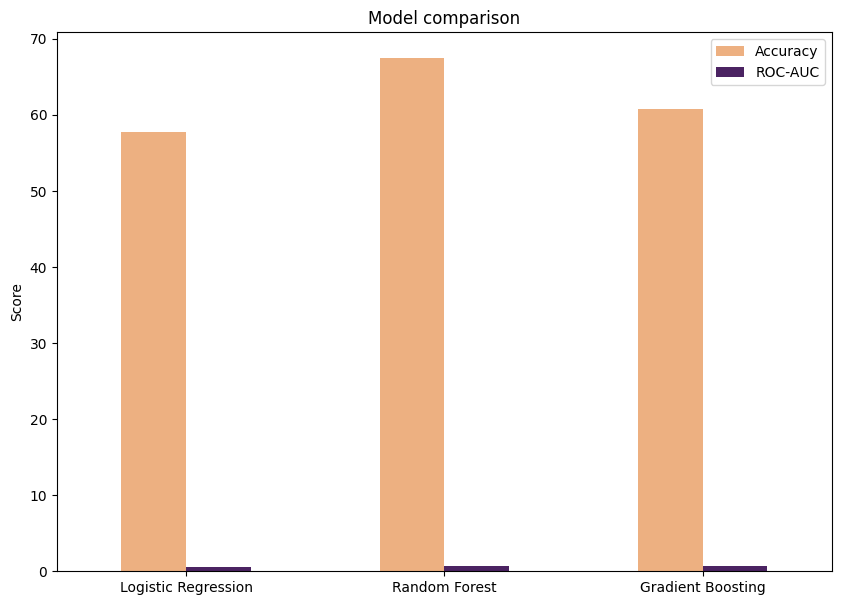

In [25]:
#plot model complarision
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10,7), colormap='flare')

plt.title("Model comparison")
plt.ylabel("Score")
plt.xticks(rotation=360)
plt.legend(loc='upper right')
plt.show()

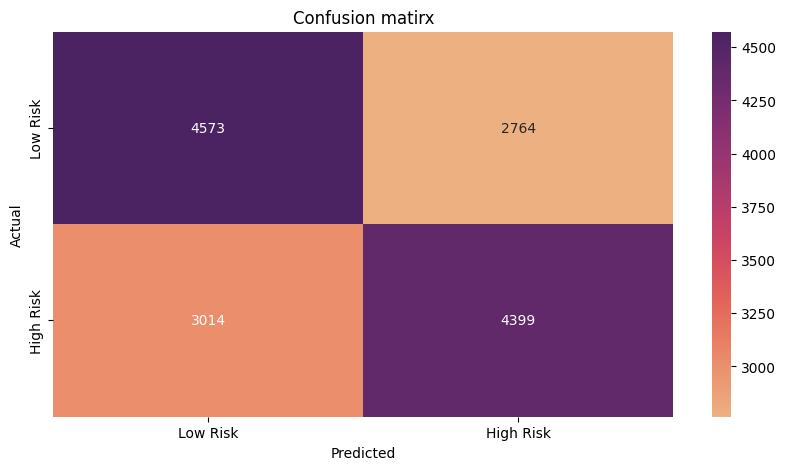

In [26]:
#confusion matrix
#using cradient boosting model
best_model = models['Gradient Boosting']
y_pred_best = best_model.predict(X_test_scaled)

#build confusion matrix
cm=confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='flare',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels= ['Low Risk', 'High Risk'])

plt.title("Confusion matirx")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

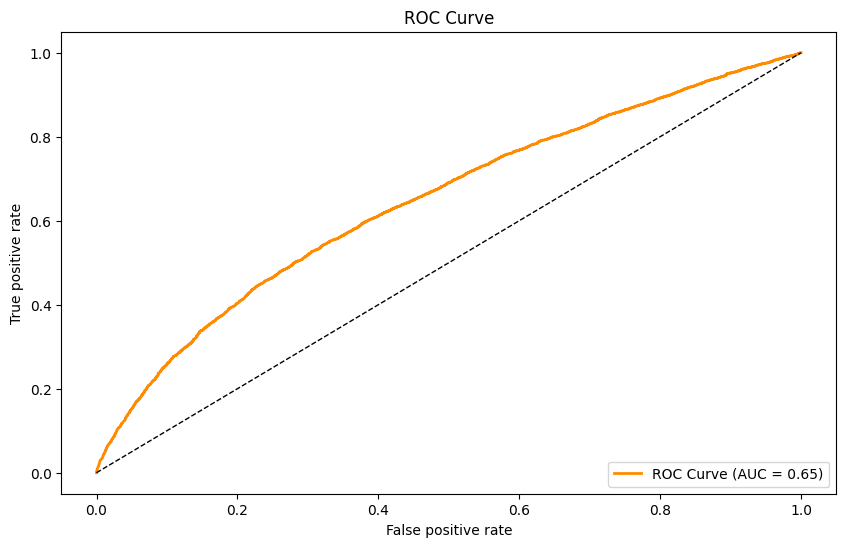

In [30]:
#ROC curve
# getting probability scores for ROC curve
fpr, tpr, _ = roc_curve(
    y_test,
    best_model.predict_proba(X_test_scaled)[:, 1]
)

#calulating AUC score for ROC curve
auc= roc_auc_score(
    y_test,
    best_model.predict_proba(X_test_scaled)[:, 1]
)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2,label=f'ROC Curve (AUC = {auc:.2f})')

#diagonal line representing random guessing
plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.title("ROC Curve")
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')
plt.show()

C:\Users\manvi\AppData\Local\Temp\ipykernel_165288\3738675613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='flare')


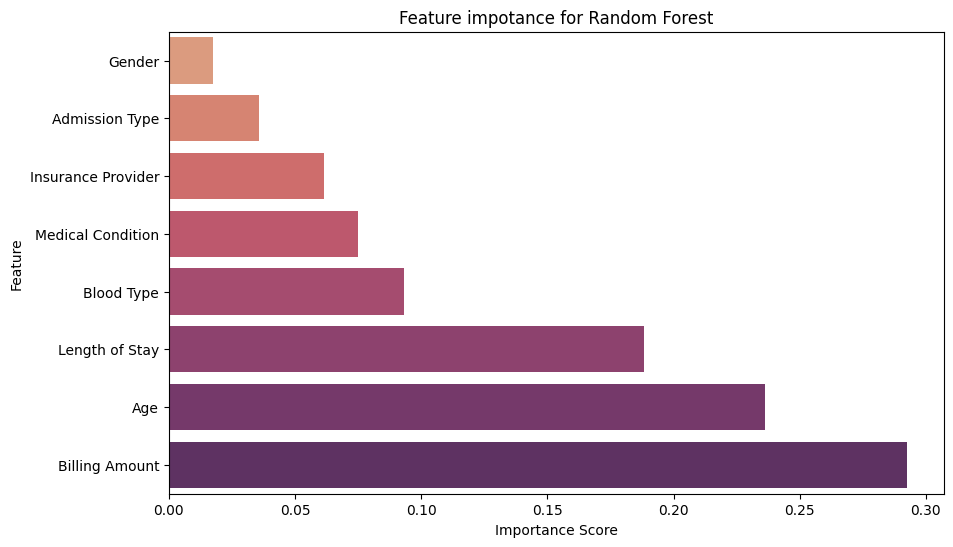

In [31]:
#feature importance
#using random forest model for feature importance

rf_model = models['Random Forest']

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='flare')
plt.title('Feature impotance for Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [39]:
import os

# Define the full path to your app folder
app_path = r'C:\Users\manvi\Personal_Projects\hospital-analytics\app'

# Create the folder if it somehow doesn't exist
os.makedirs(app_path, exist_ok=True)

# Save the best performing model
joblib.dump(best_model, os.path.join(app_path, 'model.pkl'))

# Save the scaler
joblib.dump(scaler, os.path.join(app_path, 'scaler.pkl'))

# Save feature names
feature_names = list(X.columns)
joblib.dump(feature_names, os.path.join(app_path, 'feature_names.pkl'))

['C:\\Users\\manvi\\Personal_Projects\\hospital-analytics\\app\\feature_names.pkl']